# A/B-тест: новый алгоритм ETA в приложении СберМаркета

**Важная оговорка по данным.** Доступная БД `skillbox` содержит всего 6 таблиц: `app_sess`, `customers`, `info`, `orders`, `orders_product`, `products`. В них **нет**:
- флага принадлежности пользователя к группе test/control;
- значения ETA (предсказанного или фактического времени доставки);
- событий воронки заказа (просмотр ретейлера → добавление в корзину → чекаут → выбор слота).

То есть реально проведённого эксперимента в этих данных нет, есть только исторические данные о клиентах, сессиях, заказах и доставках. Поэтому ноутбук построен в двух частях:

1. **Дизайн эксперимента** — как эксперимент должен быть устроен, если его запускать по-настоящему (это не зависит от того, какие данные нам достались).
2. **Анализ доступных данных** — используется как отработка методологии на реальных, но «грязных» данных: строится очищенный пайплайн, прокси-метрики бизнеса (средний чек, доля успешных доставок, конверсия сессия→заказ) сравниваются между двумя группами. Разбиение на группы здесь **не является настоящим экспериментальным сплитом** (в данных нет отметки, кто из пользователей видел новый ETA, а кто — старый интервал), поэтому раздел 2 нужно читать как демонстрацию того, как считался бы тест, а не как оценку реального эффекта ETA-алгоритма. Все выводы во второй части иллюстративные, а не бизнес-решение.

## 1. Дизайн эксперимента

### Гипотеза
Показ персонализированного ETA вместо фиксированного интервала «20–60 минут» повышает удовлетворённость и доверие клиентов к срокам доставки, что приводит к росту конверсии в заказ и снижению доли просроченных/неудачных доставок, не уменьшая при этом средний чек и частоту заказов.

H0: персонализированный ETA не влияет на целевые метрики.
H1: персонализированный ETA улучшает целевые метрики (направленная гипотеза: ожидаем улучшения, а не просто «отличие»).

### Точка сплита (где делить пользователей на группы)
Разбивать нужно **на уровне пользователя (`customer_id`)**, детерминированным хэшированием id (а не на уровне сессии или заказа). Причины:
- один и тот же пользователь в течение теста открывает приложение и оформляет заказы много раз, если сплитовать по сессии/заказу, один человек будет видеть то старый, то новый интервал, это создаёт противоречивый опыт и портит метрики, завязанные на доверие к срокам;
- пользователь должен получать стабильный опыт на всех трёх экранах, где показывается интервал (список ретейлеров → страница ретейлера → чекаут), иначе интервалы будут расходиться на разных шагах одной покупки.
- разбиение должно попадать в группу непосредственно перед первым показом интервала (первое открытие экрана выбора ретейлера после старта теста), чтобы не терять пользователей, которые уже были активны до его начала.

### Метрики
**Основная (target) метрика:**
- Конверсия из просмотра ретейлера/корзины в оформленный заказ (в наших данных заменяется прокси — доля клиентов с хотя бы одним заказом за период среди тех, у кого были сессии в приложении).

**Вторичные / диагностические метрики:**
- Точность прогноза (в проде: |ETA_факт − ETA_план|) — недоступна в этих данных;
- Доля успешно завершённых доставок (`is_completed_flg`) — насколько чаще заказ доезжает без срыва;
- Средний чек (`order_sum`) — чтобы убедиться, что рост конверсии не происходит за счёт более дешёвых/мелких заказов;
- Среднее число заказов на клиента — прокси retention/лояльности.

**Guardrail-метрики** (не должны ухудшиться): средний чек, доля отменённых/неуспешных доставок, время между заказами.

### Правило принятия решения
- Если основная метрика статистически значимо выросла (p < 0.05) и ни одна guardrail-метрика значимо не просела — выкатываем на 100% пользователей.
- Если основная метрика не изменилась значимо, но и не ухудшилась — можно продлить тест или расширить выборку (недостаточно мощности).
- Если guardrail-метрики значимо просели (например, упала доля успешных доставок из-за слишком оптимистичных прогнозов ETA) — откатываем и дорабатываем модель.
- Перед принятием решения обязательно проверяется SRM (sample ratio mismatch) — совпадает ли фактическое соотношение размеров групп с ожидаемым 50/50; при рассинхроне результаты теста не могут считаться надёжными.
- Так как одновременно проверяется несколько метрик (чек, доля успешных доставок, конверсия), при трактовке пограничных p-value (~0.03–0.05) стоит учитывать эффект множественных сравнений и не принимать решение по одной метрике на грани значимости без подтверждения на повторном тесте.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


def proportions_ztest(count, nobs):
    '''Двухвыборочный z-test для разности долей (пуловая дисперсия).
    Реализован вручную на scipy, чтобы не тянуть внешнюю зависимость statsmodels
    только ради одной функции; формула стандартная (как в statsmodels.stats.proportion.proportions_ztest).'''
    count = np.asarray(count, dtype=float)
    nobs = np.asarray(nobs, dtype=float)
    p_pool = count.sum() / nobs.sum()
    p1, p2 = count[0] / nobs[0], count[1] / nobs[1]
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / nobs[0] + 1 / nobs[1]))
    z = (p1 - p2) / se
    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p_value


app_sess = pd.read_csv('app_sess.csv')
customers = pd.read_csv('customers.csv')
info = pd.read_csv('info.csv')
orders = pd.read_csv('orders.csv')
orders_product = pd.read_csv('orders_product.csv')
products = pd.read_csv('products.csv')

print("Размеры исходных таблиц:")
for name, df in [('app_sess', app_sess), ('customers', customers), ('info', info),
                  ('orders', orders), ('orders_product', orders_product), ('products', products)]:
    print(f"  {name}: {df.shape}")

Размеры исходных таблиц:
  app_sess: (5336, 5)
  customers: (501, 7)
  info: (3039, 4)
  orders: (2950, 4)
  orders_product: (5990, 3)
  products: (15, 4)


In [2]:
for name, df in [('orders', orders), ('app_sess', app_sess), ('customers', customers),
                  ('info', info), ('orders_product', orders_product), ('products', products)]:
    print(f"=== {name} ===")
    display(df.head(3))
    print(df.dtypes)
    print("пропуски:\n", df.isna().sum())
    print("-" * 50)

=== orders ===


,order_id,customer_id,order_dt,payment_method
0,99983,4951223,07.12.2021,offline
1,99969,1806908,29.07.2022,offline
2,99868,2576384,27.09.2021,online


order_id           int64
customer_id        int64
order_dt          object
payment_method    object
dtype: object
пропуски:
 order_id          0
customer_id       0
order_dt          0
payment_method    0
dtype: int64
--------------------------------------------------
=== app_sess ===


,session_id,customer_id,start_dttm,finish_dttm,device_name
0,1,4374148,08.01.20 3:37,09.01.20 6:29,iOS
1,2,1587527,19.02.23 16:45,20.02.23 18:16,Windows
2,3,7864358,25.01.20 10:36,26.01.20 22:32,iOS


session_id      int64
customer_id     int64
start_dttm     object
finish_dttm    object
device_name    object
dtype: object
пропуски:
 session_id     0
customer_id    0
start_dttm     0
finish_dttm    0
device_name    0
dtype: int64
--------------------------------------------------
=== customers ===


...

delivery_id          int64
order_id             int64
delivery_dt         object
is_completed_flg      bool
dtype: object
пропуски:
 delivery_id         0
order_id            0
delivery_dt         0
is_completed_flg    0
dtype: int64
--------------------------------------------------
=== orders_product ===


,order_id,product_id,amount
0,52414,4,33
1,73440,3,50
2,39895,9,5


order_id      int64
product_id    int64
amount        int64
dtype: object
пропуски:
 order_id      0
product_id    0
amount        0
dtype: int64
--------------------------------------------------
=== products ===


,product_id,product_group_name,product_name,Price
0,1,Одежда,Носки,500
1,2,Одежда,Штаны,2100
2,3,Одежда,Юбка,10000


product_id             int64
product_group_name    object
product_name          object
Price                  int64
dtype: object
пропуски:
 product_id            0
product_group_name    0
product_name          0
Price                 0
dtype: int64
--------------------------------------------------


## 2. Проверка качества данных

Перед объединением таблиц нашлись проблемы, которые нужно устранить, иначе метрики будут искажены:

1. **Дубли в `info`**: у одного `order_id` может быть несколько записей о доставке (разные попытки/переносы) — до 6 строк на заказ. Если мёржить `orders` с `info` напрямую по `order_id`, один заказ размножится на несколько строк, и средний чек / доля успешных доставок посчитаются неверно (заказ с 5 попытками будет "весить" в 5 раз больше заказа с одной).
2. **"Осиротевшие" `customer_id`**: часть заказов ссылается на клиентов, которых нет в `customers`.
3. **Пустая строка в `customers`**: одна строка полностью NaN, из-за неё `customer_id` в этой таблице имеет тип `float64` вместо `int64`.
4. **Заказы без строк в `orders_product`**: часть `order_id` из `orders` вообще не встречается в `orders_product`, по ним не из чего посчитать состав и сумму заказа. После мёржа это даёт `order_sum = NaN`; такие заказы автоматически выпадают из среднего чека и статистических тестов по чеку (через `.dropna()`), но не участвуют и в подсчёте доли успешных доставок — это отдельная, самостоятельная проблема данных, не связанная с дублями в `info`.

Дальше эти проблемы устраняются явно, с выводом промежуточных цифр, чтобы было видно, что именно изменилось.

In [3]:
dup_orders_in_info = info['order_id'].value_counts()
n_dup_orders = (dup_orders_in_info > 1).sum()
print(f"Заказов с несколькими записями в info: {n_dup_orders} из {info['order_id'].nunique()} уникальных заказов "
      f"({info.shape[0]} строк в info)")

orphan_customers = set(orders['customer_id']) - set(customers['customer_id'].dropna())
print(f"customer_id в orders, отсутствующих в customers: {len(orphan_customers)}")

print(f"Полностью пустых строк в customers: {customers.isna().all(axis=1).sum()}")

orders_without_products = set(orders['order_id']) - set(orders_product['order_id'])
print(f"order_id из orders, отсутствующих в orders_product: {len(orders_without_products)} "
      f"из {orders['order_id'].nunique()} ({len(orders_without_products) / orders['order_id'].nunique():.1%})")

Заказов с несколькими записями в info: 815 из 1871 уникальных заказов (3039 строк в info)
customer_id в orders, отсутствующих в customers: 5
Полностью пустых строк в customers: 1
order_id из orders, отсутствующих в orders_product: 315 из 2950 (10.7%)


In [4]:
# 1. Чистка customers: убираю пустую строку, привожу id к целому типу
customers_clean = customers.dropna(subset=['customer_id']).copy()
customers_clean['customer_id'] = customers_clean['customer_id'].astype('int64')

# 2. Схлопываю info до одной строки на заказ:
#    заказ считаем успешным, если хотя бы одна попытка доставки была успешной (is_completed_flg = True),
#    отдельно сохраняю число попыток доставки (attempts), сама по себе полезная диагностическая метрика
info_agg = info.groupby('order_id').agg(
    is_completed_flg=('is_completed_flg', 'max'),
    delivery_attempts=('delivery_id', 'count'),
    last_delivery_dt=('delivery_dt', 'max')
).reset_index()

print(f"info после схлопывания: {info_agg.shape[0]} строк (было {info.shape[0]})")

# 3. Подсчет суммы и состава каждого заказа
#    внимание: цены в products.csv учебные (например, "Часы с кукушкой" = 90000), поэтому order_sum
#    получается в диапазоне сотен тысяч рублей, это особенность датасета, а не ошибка мёржа.
orders_product_full = orders_product.merge(products, on='product_id', how='left')
orders_product_full['item_cost'] = orders_product_full['amount'] * orders_product_full['Price']

order_totals = orders_product_full.groupby('order_id').agg(
    order_sum=('item_cost', 'sum'),
    items_count=('amount', 'sum')
).reset_index()

# 4. Сборка итогового датасета на уровне заказа
df_orders = (
    orders
    .merge(info_agg, on='order_id', how='left')
    .merge(order_totals, on='order_id', how='left')
    .merge(customers_clean[['customer_id', 'address']], on='customer_id', how='left')
)

print(f"orders: {orders.shape[0]} строк -> df_orders: {df_orders.shape[0]} строк (дублей заказов быть не должно)")
assert df_orders['order_id'].is_unique, "После сборки в df_orders не должно быть дублей order_id"

print(f"Заказов без данных о доставке (нет в info): {df_orders['is_completed_flg'].isna().sum()}")
print(f"Заказов от 'осиротевших' клиентов (нет данных клиента): {df_orders['address'].isna().sum()}")
print(f"Заказов без суммы (нет строк в orders_product): {df_orders['order_sum'].isna().sum()}")

display(df_orders.head(3))

info после схлопывания: 1871 строк (было 3039)
orders: 2950 строк -> df_orders: 2950 строк (дублей заказов быть не должно)
Заказов без данных о доставке (нет в info): 1079
Заказов от 'осиротевших' клиентов (нет данных клиента): 5
Заказов без суммы (нет строк в orders_product): 315


,order_id,customer_id,order_dt,payment_method,is_completed_flg,delivery_attempts,last_delivery_dt,order_sum,items_count,address
0,99983,4951223,07.12.2021,offline,True,4.0,24-12-2021,247000.0,38.0,Уссурийск
1,99969,1806908,29.07.2022,offline,True,4.0,31-08-2022,42680.0,48.0,Волжский
2,99868,2576384,27.09.2021,online,NaN,NaN,NaN,56080.0,74.0,Сертолово


## 3. Разбиение на группы

Как отмечено во введении, в данных нет реальной отметки, кто из пользователей видел новый ETA, а кто — старый интервал. Ниже группы формируются **детерминированным хэшированием `customer_id`**: это ближе к тому, как реальный сплит делается в проде (один и тот же пользователь всегда попадает в одну и ту же группу, результат не зависит от `random_state` и воспроизводится без сохранения списка id).

Это разбиение **не создаёт никакого реального различия в продукте** между группами (обе видели одно и то же приложение), поэтому статистически значимых различий по метрикам мы, скорее всего, *не увидим и не должны увидеть*, это ожидаемый результат, а не вывод об отсутствии эффекта ETA-алгоритма. Ниже это разбиение используется только чтобы показать сам процесс проверки (SRM, тесты, визуализация), который в реальном тесте применялся бы к настоящим группам.

In [5]:
import hashlib

def assign_group(customer_id: int) -> str:
    h = hashlib.md5(str(int(customer_id)).encode()).hexdigest()
    return 'test' if int(h, 16) % 2 == 0 else 'control'

df_orders['experiment_group'] = df_orders['customer_id'].apply(assign_group)

# SRM-проверка: goodness-of-fit хи-квадрат теста наблюдаемых размеров групп против ожидаемых 50/50.
# важно использовать именно chisquare (сравнение наблюдаемых частот с ожидаемыми), а не chi2_contingency
# на сконструированной 2x2-таблице, во втором случае по умолчанию применяется поправка Йейтса
# и p-value для этой же проверки получается другим (не тот тест, который реально нужен для SRM).
group_sizes = df_orders.drop_duplicates('customer_id')['experiment_group'].value_counts()
print("Размеры групп (уникальные пользователи):")
print(group_sizes)

expected = [group_sizes.sum() / 2] * len(group_sizes)
chi2_srm, p_srm = stats.chisquare(f_obs=group_sizes.values, f_exp=expected)
print(f"\nSRM chi-square goodness-of-fit test: chi2 = {chi2_srm:.4f}, p-value = {p_srm:.4f}")
print("Соотношение групп ожидаемо (нет SRM)" if p_srm >= 0.01 else "ВНИМАНИЕ: подозрение на SRM!")

Размеры групп (уникальные пользователи):
experiment_group
control    254
test       247
Name: count, dtype: int64

SRM chi-square goodness-of-fit test: chi2 = 0.0978, p-value = 0.7545
Соотношение групп ожидаемо (нет SRM)


In [6]:
# прокси-метрика воронки: конверсия "были активны в приложении" -> "оформили заказ"
# (в реальных данных СберМаркета конверсию считали бы по событиям воронки внутри одной сессии;
#  здесь событий воронки нет, поэтому берётся более грубый прокси на уровне пользователя за весь период)

customers_with_group = customers_clean[['customer_id']].copy()
customers_with_group['experiment_group'] = customers_with_group['customer_id'].apply(assign_group)

had_session = set(app_sess['customer_id'].unique())
had_order = set(orders['customer_id'].unique())

customers_with_group['had_session'] = customers_with_group['customer_id'].isin(had_session)
customers_with_group['had_order'] = customers_with_group['customer_id'].isin(had_order)

# Конверсию считаем только среди тех, у кого была хотя бы одна сессия в приложении
active_customers = customers_with_group[customers_with_group['had_session']].copy()
print(f"Клиентов с сессиями в приложении: {active_customers.shape[0]} из {customers_with_group.shape[0]}")

display(active_customers.groupby('experiment_group')['had_order'].agg(['mean', 'count']))

Клиентов с сессиями в приложении: 500 из 500


,mean,count
experiment_group,,
control,1.000000,251
test,0.983936,249


In [7]:
orders_per_customer = df_orders.groupby(['experiment_group', 'customer_id']).size().reset_index(name='n_orders')

summary_metrics = df_orders.groupby('experiment_group').agg(
    orders_count=('order_id', 'count'),
    unique_customers=('customer_id', 'nunique'),
    success_delivery_rate=('is_completed_flg', 'mean'),
    avg_order_value=('order_sum', 'mean'),
    median_order_value=('order_sum', 'median')
).reset_index()

summary_metrics = summary_metrics.merge(
    orders_per_customer.groupby('experiment_group')['n_orders'].mean().rename('avg_orders_per_customer'),
    on='experiment_group'
)

summary_metrics = summary_metrics.merge(
    active_customers.groupby('experiment_group')['had_order'].mean().rename('session_to_order_conversion'),
    on='experiment_group'
)

print("Метрики по группам (иллюстративное разбиение, не реальный эксперимент):")
display(summary_metrics)

Метрики по группам (иллюстративное разбиение, не реальный эксперимент):


,experiment_group,orders_count,unique_customers,success_delivery_rate,avg_order_value,median_order_value,avg_orders_per_customer,session_to_order_conversion
0,control,1522,254,0.631633,479378.650037,57500.0,5.992126,1.000000
1,test,1428,247,0.624018,514078.415881,63000.0,5.781377,0.983936


In [8]:
def ci_proportion(count, nobs, alpha=0.05):
    p = count / nobs
    z = stats.norm.ppf(1 - alpha / 2)
    se = np.sqrt(p * (1 - p) / nobs)
    return p, (p - z * se, p + z * se)

print("=" * 60)
print("1) Средний чек: Welch t-test + Mann-Whitney U (робастность к скошенности)")
control_checks = df_orders.loc[df_orders['experiment_group'] == 'control', 'order_sum'].dropna()
test_checks = df_orders.loc[df_orders['experiment_group'] == 'test', 'order_sum'].dropna()

t_stat, p_t = stats.ttest_ind(control_checks, test_checks, equal_var=False)
u_stat, p_u = stats.mannwhitneyu(control_checks, test_checks, alternative='two-sided')
print(f"Welch t-test:      p-value = {p_t:.4f}")
print(f"Mann-Whitney U:    p-value = {p_u:.4f}")
print(f"Средний чек control = {control_checks.mean():.0f}, test = {test_checks.mean():.0f}")
print(f"(учтено {len(control_checks) + len(test_checks)} заказов с известной суммой из "
      f"{df_orders.shape[0]}; заказы без строк в orders_product исключены)")

print("\n" + "=" * 60)
print("2) Доля успешных доставок: z-test для долей")
success = df_orders.dropna(subset=['is_completed_flg'])
succ_control = success.loc[success['experiment_group'] == 'control', 'is_completed_flg'].astype(int)
succ_test = success.loc[success['experiment_group'] == 'test', 'is_completed_flg'].astype(int)

count = [succ_test.sum(), succ_control.sum()]
nobs = [len(succ_test), len(succ_control)]
z_stat, p_z = proportions_ztest(count, nobs)

p_test, ci_test = ci_proportion(count[0], nobs[0])
p_control, ci_control = ci_proportion(count[1], nobs[1])
print(f"p-value = {p_z:.4f}")
print(f"control: {p_control:.3f}  95% CI [{ci_control[0]:.3f}, {ci_control[1]:.3f}]  (n={nobs[1]})")
print(f"test:    {p_test:.3f}  95% CI [{ci_test[0]:.3f}, {ci_test[1]:.3f}]  (n={nobs[0]})")

print("\n" + "=" * 60)
print("3) Конверсия сессия -> заказ: z-test для долей")
conv_control = active_customers.loc[active_customers['experiment_group'] == 'control', 'had_order'].astype(int)
conv_test = active_customers.loc[active_customers['experiment_group'] == 'test', 'had_order'].astype(int)

count_c = [conv_test.sum(), conv_control.sum()]
nobs_c = [len(conv_test), len(conv_control)]
z_stat_c, p_z_c = proportions_ztest(count_c, nobs_c)
print(f"p-value = {p_z_c:.4f}")
print(f"control conversion = {conv_control.mean():.3f} (n={nobs_c[1]}), "
      f"test conversion = {conv_test.mean():.3f} (n={nobs_c[0]})")

print("\n" + "=" * 60)
alpha = 0.05
for label, p in [("средний чек", p_t), ("доля успешных доставок", p_z), ("конверсия сессия->заказ", p_z_c)]:
    verdict = "статистически значимое отличие" if p < alpha else "значимого отличия нет"
    print(f"{label}: p={p:.4f} -> {verdict}")

n_tests = 3
print(f"\nПроверено метрик за раз: {n_tests}. При множественных сравнениях порог 0.05 на метрику "
      f"даёт повышенный шанс случайно получить p<0.05 хотя бы по одной из них "
      f"(ориентировочно 1-(1-0.05)^{n_tests} ≈ {1 - (1 - alpha) ** n_tests:.1%}) — это ещё один аргумент "
      f"не доверять единичному пограничному p-value (как p=0.044 у конверсии) без перепроверки.")

1) Средний чек: Welch t-test + Mann-Whitney U (робастность к скошенности)
Welch t-test:      p-value = 0.3770
Mann-Whitney U:    p-value = 0.7014
Средний чек control = 479379, test = 514078
(учтено 2635 заказов с известной суммой из 2950; заказы без строк в orders_product исключены)

2) Доля успешных доставок: z-test для долей
p-value = 0.7336
control: 0.632  95% CI [0.601, 0.662]  (n=980)
test:    0.624  95% CI [0.592, 0.656]  (n=891)

3) Конверсия сессия -> заказ: z-test для долей
p-value = 0.0438
control conversion = 1.000 (n=251), test conversion = 0.984 (n=249)

средний чек: p=0.3770 -> значимого отличия нет
доля успешных доставок: p=0.7336 -> значимого отличия нет
конверсия сессия->заказ: p=0.0438 -> статистически значимое отличие

Проверено метрик за раз: 3. При множественных сравнениях порог 0.05 на метрику даёт повышенный шанс случайно получить p<0.05 хотя бы по одной из них (ориентировочно 1-(1-0.05)^3 ≈ 14.3%) — это ещё один аргумент не доверять единичному пограничному p-val

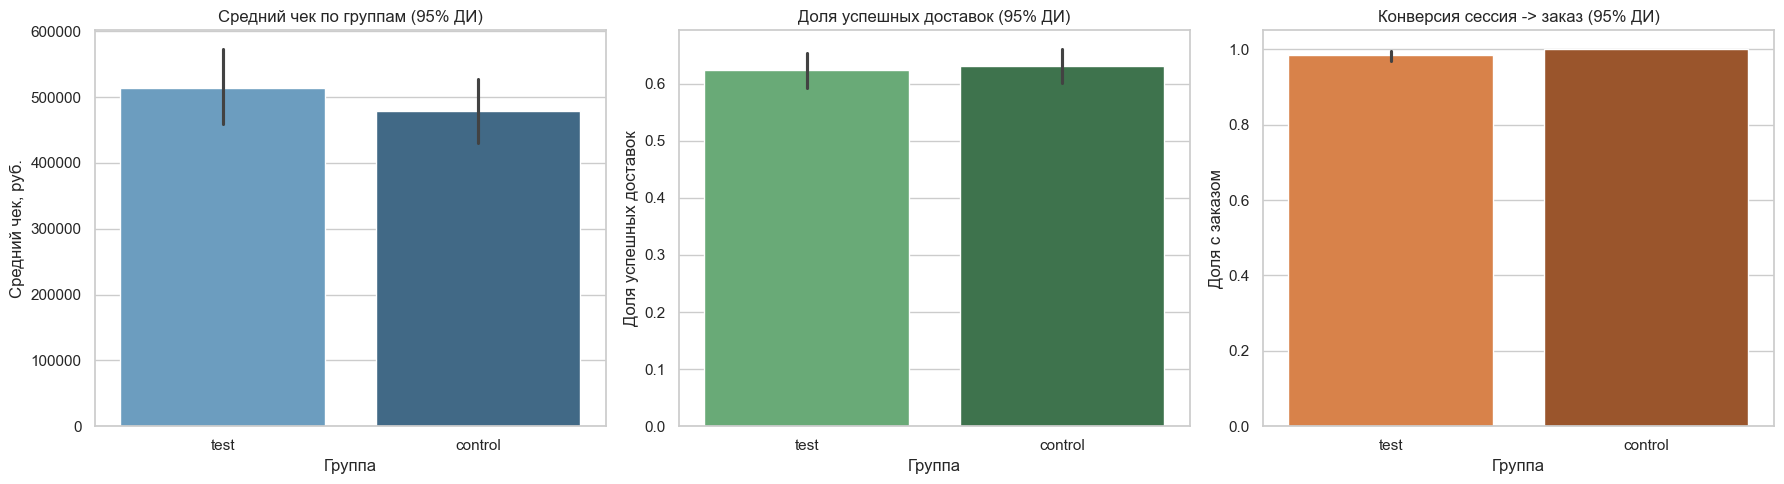

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df_orders, x='experiment_group', y='order_sum', hue='experiment_group',
            estimator='mean', errorbar=('ci', 95), palette='Blues_d', legend=False, ax=axes[0])
axes[0].set_title('Средний чек по группам (95% ДИ)')
axes[0].set_xlabel('Группа')
axes[0].set_ylabel('Средний чек, руб.')

success_plot = df_orders.dropna(subset=['is_completed_flg']).copy()
success_plot['is_completed_flg'] = success_plot['is_completed_flg'].astype(int)
sns.barplot(data=success_plot, x='experiment_group', y='is_completed_flg', hue='experiment_group',
            estimator='mean', errorbar=('ci', 95), palette='Greens_d', legend=False, ax=axes[1])
axes[1].set_title('Доля успешных доставок (95% ДИ)')
axes[1].set_xlabel('Группа')
axes[1].set_ylabel('Доля успешных доставок')

active_plot = active_customers.copy()
active_plot['had_order'] = active_plot['had_order'].astype(int)
sns.barplot(data=active_plot, x='experiment_group', y='had_order', hue='experiment_group',
            estimator='mean', errorbar=('ci', 95), palette='Oranges_d', legend=False, ax=axes[2])
axes[2].set_title('Конверсия сессия -> заказ (95% ДИ)')
axes[2].set_xlabel('Группа')
axes[2].set_ylabel('Доля с заказом')

plt.tight_layout()
plt.show()

## 4. Выводы и рекомендации

**По разделу 1 (дизайн эксперимента)** — если тест запускать по-настоящему:
- сплит на уровне `customer_id`, детерминированным хэшем, перед первым показом интервала доставки;
- основная метрика — конверсия из просмотра ретейлера в оформленный заказ, guardrail — средний чек и доля успешных доставок;
- перед оценкой эффекта обязательно проверять SRM.

**По разделу 2 (анализ доступных данных)** — средний чек и доля успешных доставок ожидаемо не различаются (p ≥ 0.05): разбиение на группы в этих данных не связано ни с каким реальным изменением в продукте, поэтому отсутствие различий — не вывод об эффективности/неэффективности ETA-алгоритма, а подтверждение того, что искусственный сплит действительно ничего не разделяет. Конверсия «сессия → заказ» формально дала p≈0.04, но это тоже не сигнал: метрика близка к потолку (98–100% активных клиентов и так заказали хоть раз за всю историю), при таком эффекте потолка даже случайное разбиение может давать «значимую» разницу в 1–2 заказа; вдобавок при трёх проверяемых метриках шанс случайно получить хотя бы один p<0.05 заметно выше 5% (см. расчёт в разделе со статтестами) — это артефакт метрики, малой выборки и множественных сравнений, а не эффект теста. Ценность этой части в методологии (очистка дублей в `info`, честный учёт "осиротевших" клиентов и заказов без строк в `orders_product`, SRM-проверка через корректный goodness-of-fit тест, выбор t-test/Mann-Whitney/z-test под тип метрики, доверительные интервалы на графиках), которую можно один в один применить, когда появятся реальные данные о группах теста.

**Что нужно добавить в продукт/БД, чтобы тест можно было проанализировать по-настоящему:**
1. Флаг `experiment_group` (test/control) на уровне пользователя, проставляемый в момент попадания в тест.
2. Логирование показанного ETA (диапазон) и фактического времени доставки для расчёта точности прогноза, ключевой цели алгоритма.
3. События воронки заказа (просмотр списка ретейлеров, открытие карточки ретейлера, добавление в корзину, открытие чекаута, выбор слота, оформление), чтобы считать целевую метрику конверсии так, как она определена в дизайне эксперимента, а не приблизительным прокси.

**Ограничения текущего анализа:**
- прокси-метрика конверсии "сессия -> заказ" грубее, чем настоящая пошаговая воронка, и не учитывает, что часть сессий вообще не связана с покупками (самовывоз, плановая доставка);
- нет данных за какой-то конкретный период теста — использована вся история, что могло смешать разные годы/сезонность;
- 5 заказов от клиентов без карточки в `customers` не исключались из расчёта чека и доставки (это не мешает, так как для этих метрик не нужны персональные поля), но исключены из воронки, поскольку прокси считался от таблицы `customers`;
- около 10-11% заказов не имеют строк в `orders_product`, поэтому их сумма неизвестна и они не участвуют в расчёте среднего чека — это часть данных, недоступная по объективной причине (не ошибка обработки), но потенциальный источник смещения, если отсутствие данных не случайно (например, если это заказы определённого типа доставки);
- абсолютные значения `order_sum` (сотни тысяч рублей на заказ) — следствие учебных цен в `products.csv`, а не реальных чеков СберМаркета; для целей сравнения групп внутри одного датасета это не проблема, но эти цифры нерепрезентативны для реального бизнеса.